<a href="https://colab.research.google.com/github/Lyv-ux/DI_Bootcamp/blob/main/W4D3ExercisesXP_Heart_Student.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Exercises XP - Heart Disease Prediction (Student, Hints Only)

## What you will learn
- Load and inspect CSV data
- EDA and preprocessing
- Train Logistic Regression, SVM, XGBoost
- Hyperparameter tuning with GridSearchCV
- Evaluate with standard metrics

## What you will create
- Working classifiers and a simple comparison report


## Setup

In [1]:
import os, zipfile, glob
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, roc_curve, confusion_matrix
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC

# Hint: install xgboost in Colab if missing
!pip install xgboost
try:
    from xgboost import XGBClassifier
except Exception:
    XGBClassifier = None

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)


## Exercise 1 - Exploratory Data Analysis

In [28]:
import zipfile

# TODO: extract the dataset zip to an output folder
ZIP_PATH = 'Heart Disease Prediction Dataset.zip'  # or your path
EXTRACT_DIR = 'heart_ds'
# Hint: use zipfile.ZipFile(ZIP_PATH).extractall(EXTRACT_DIR)
with zipfile.ZipFile(ZIP_PATH, 'r') as zip_ref:
    zip_ref.extractall(EXTRACT_DIR)

# TODO: list CSV files under EXTRACT_DIR
import os
import glob
csv_files = glob.glob(os.path.join(EXTRACT_DIR, '*.csv'))
if csv_files:
    csv_path = csv_files[0]  # set to the CSV you choose
else:
    csv_path = None
print(f"Using CSV file: {csv_path}")

# TODO: load the CSV into a DataFrame named df
import pandas as pd
df = pd.read_csv(csv_path)

# TODO: inspect df
from IPython.display import display
display(df.head())
display(df.info())

# TODO: identify target column
target = 'heart disease'  # 'target'

# TODO: split features and target
X = df.drop(columns=[target])  # df.drop(columns=[...])
y = df[target]

# Remap target values from [1, 2] to [0, 1] for compatibility with some classifiers
y = y - 1

# TODO: train test split with stratification
from sklearn.model_selection import train_test_split
# RANDOM_STATE is defined in setup cell
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y)
# Hint: train_test_split(X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y)

print(f"X_train shape: {X_train.shape}")
print(f"X_test shape: {X_test.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"y_test shape: {y_test.shape}")

Using CSV file: heart_ds/dataset_heart.csv


,age,sex,chest pain type,resting blood pressure,serum cholestoral,fasting blood sugar,resting electrocardiographic results,max heart rate,exercise induced angina,oldpeak,ST segment,major vessels,thal,heart disease
0,70,1,4,130,322,0,2,109,0,2.4,2,3,3,2
1,67,0,3,115,564,0,2,160,0,1.6,2,0,7,1
2,57,1,2,124,261,0,0,141,0,0.3,1,0,7,2
3,64,1,4,128,263,0,0,105,1,0.2,2,1,7,1
4,74,0,2,120,269,0,2,121,1,0.2,1,1,3,1


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 270 entries, 0 to 269
Data columns (total 14 columns):
 #   Column                                Non-Null Count  Dtype  
---  ------                                --------------  -----  
 0   age                                   270 non-null    int64  
 1   sex                                   270 non-null    int64  
 2   chest pain type                       270 non-null    int64  
 3   resting blood pressure                270 non-null    int64  
 4   serum cholestoral                     270 non-null    int64  
 5   fasting blood sugar                   270 non-null    int64  
 6   resting electrocardiographic results  270 non-null    int64  
 7   max heart rate                        270 non-null    int64  
 8   exercise induced angina               270 non-null    int64  
 9   oldpeak                               270 non-null    float64
 10  ST segment                            270 non-null    int64  
 11  major vessels      

None

X_train shape: (216, 13)
X_test shape: (54, 13)
y_train shape: (216,)
y_test shape: (54,)


### Basic visual checks

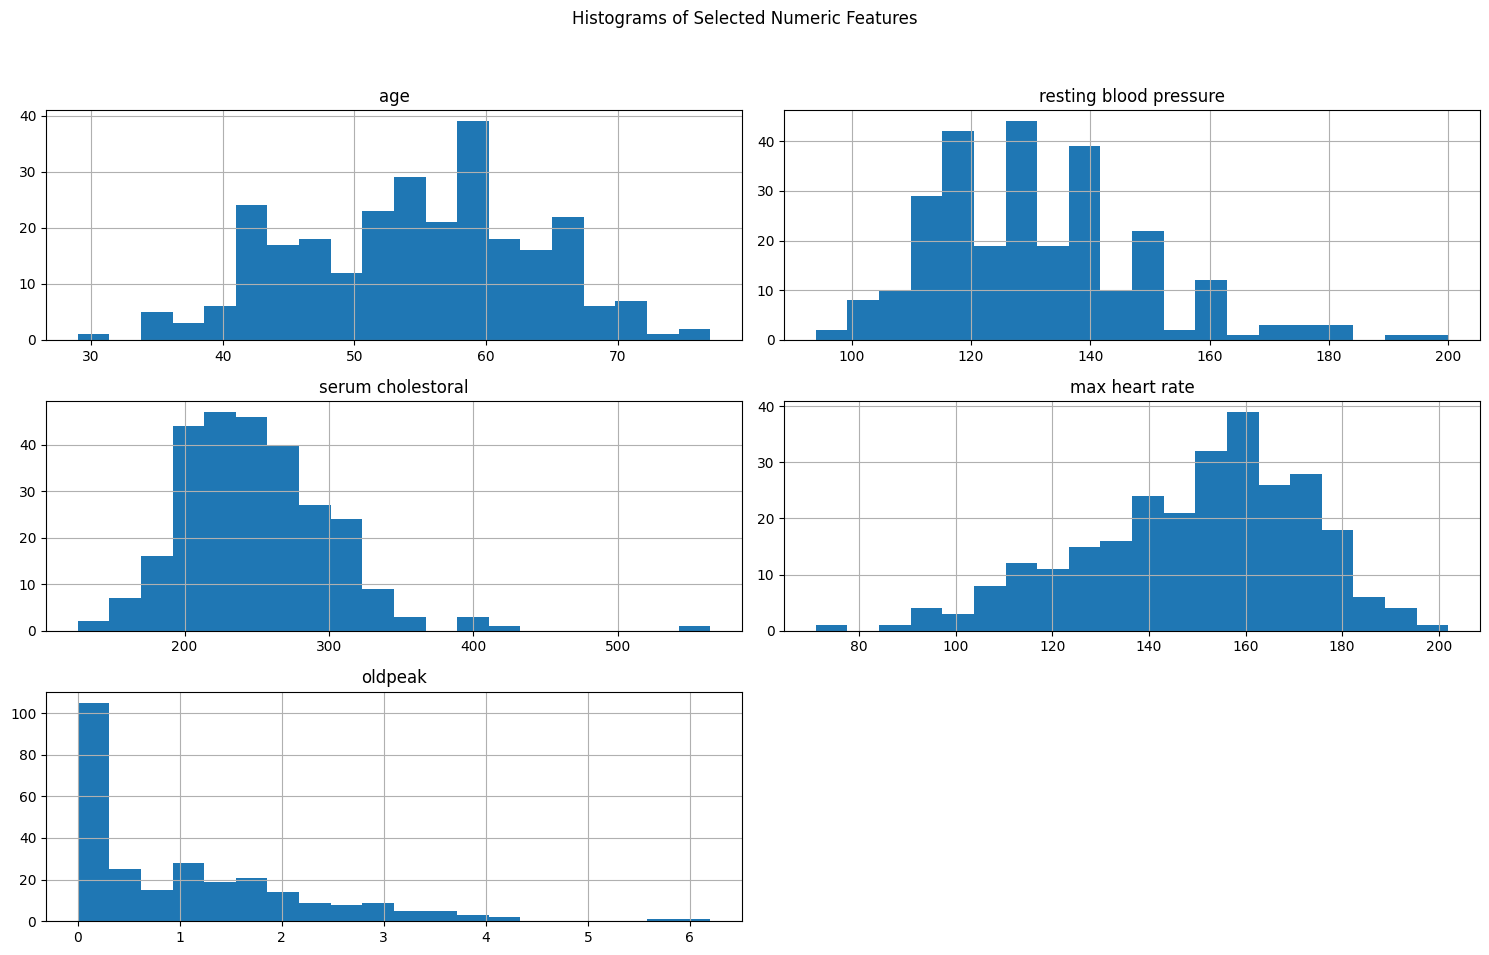

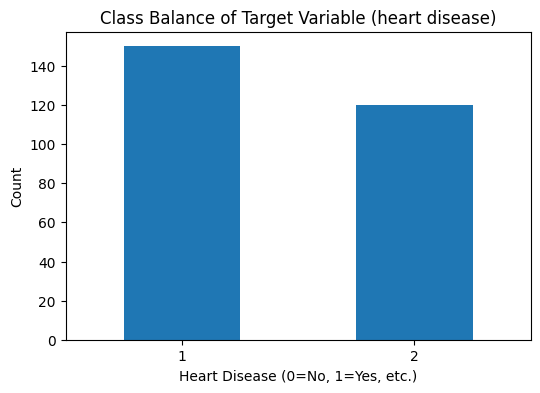

In [20]:
# TODO: pick a few numeric columns and plot histograms
numeric_cols_for_hist = ['age', 'resting blood pressure', 'serum cholestoral', 'max heart rate', 'oldpeak']
df[numeric_cols_for_hist].hist(figsize=(15, 10), bins=20)
plt.suptitle('Histograms of Selected Numeric Features')
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

# TODO: plot class balance as a bar chart
plt.figure(figsize=(6, 4))
y.value_counts().plot(kind='bar')
plt.title('Class Balance of Target Variable (heart disease)')
plt.xlabel('Heart Disease (0=No, 1=Yes, etc.)')
plt.ylabel('Count')
plt.xticks(rotation=0)
plt.show()


## Preprocessing pipeline

In [21]:
cat_cols = X.select_dtypes(include=['object', 'category', 'bool', 'int64']).columns.tolist() # list of object, category, or bool columns
num_cols = X.select_dtypes(include=['float64']).columns.tolist()  # list of numeric columns

# Some integer columns might be categorical. Let's inspect unique values for 'chest pain type', 'sex', etc.
# For simplicity here, assuming all int64 columns are categorical for one-hot encoding if they have few unique values.
# More rigorous analysis would involve domain knowledge or value counts.

# Let's refine cat_cols and num_cols based on unique values if they are int64
for col in X.select_dtypes(include=['int64']).columns:
    if X[col].nunique() < 10: # Heuristic: if less than 10 unique values, consider it categorical
        if col not in cat_cols: # Add if not already there from initial select_dtypes
            cat_cols.append(col)
        if col in num_cols: # Remove from num_cols if it was there
            num_cols.remove(col)
    else:
        if col not in num_cols: # Add to num_cols if not already there
            num_cols.append(col)
        if col in cat_cols: # Remove from cat_cols if it was there (e.g. from 'int64')
            cat_cols.remove(col)

# Ensure no overlap and all columns are covered
all_cols = set(cat_cols + num_cols)
missing_cols = set(X.columns) - all_cols
if missing_cols:
    print(f"Warning: The following columns are not categorized: {missing_cols}")

print(f"Categorical columns: {cat_cols}")
print(f"Numerical columns: {num_cols}")


# TODO: build a ColumnTransformer named pre
pre = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), num_cols),
        ('cat', OneHotEncoder(handle_unknown='ignore'), cat_cols)
    ],
    remainder='passthrough'
)


Categorical columns: ['sex ', 'chest pain type', 'fasting blood sugar', 'resting electrocardiographic results', 'exercise induced angina', 'ST segment', 'major vessels', 'thal']
Numerical columns: ['oldpeak', 'age', 'resting blood pressure', 'serum cholestoral', 'max heart rate']


## Helper - evaluation function

In [31]:
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, roc_curve, confusion_matrix, ConfusionMatrixDisplay

def eval_and_report(name, model, X_test, y_test):
    """Compute metrics and draw confusion matrix and ROC if available.
    Fill in the missing parts.
    """
    # TODO: predictions
    y_pred = model.predict(X_test)

    # TODO: compute metrics dict with accuracy, precision, recall, f1
    metrics = {
        'accuracy': accuracy_score(y_test, y_pred),
        'precision': precision_score(y_test, y_pred, average='weighted', zero_division=0),
        'recall': recall_score(y_test, y_pred, average='weighted', zero_division=0),
        'f1': f1_score(y_test, y_pred, average='weighted', zero_division=0),
    }
    print(f"{name} Metrics: {metrics}")

    # TODO: confusion matrix plot
    # Hint: confusion_matrix(y_test, y_pred)
    # Draw with plt.imshow or ConfusionMatrixDisplay
    cm = confusion_matrix(y_test, y_pred)
    # The target labels are now 0 and 1, so the classes should be consistent
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=[0, 1])
    fig, ax = plt.subplots(figsize=(6, 6))
    disp.plot(ax=ax, cmap=plt.cm.Blues)
    ax.set_title(f'Confusion Matrix for {name}')
    plt.show()

    # TODO: ROC curve if model has predict_proba
    if hasattr(model, 'predict_proba'):
        y_proba = model.predict_proba(X_test)[:, 1] # Assuming binary classification and positive class is 1
        # After remapping, the positive label is 1, not 2
        fpr, tpr, _ = roc_curve(y_test, y_proba, pos_label=1)
        roc_auc = roc_auc_score(y_test, y_proba, multi_class='ovr')

        plt.figure(figsize=(6, 6))
        plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (area = {roc_auc:.2f})')
        plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
        plt.xlim([0.0, 1.0])
        plt.ylim([0.0, 1.05])
        plt.xlabel('False Positive Rate')
        plt.ylabel('True Positive Rate')
        plt.title(f'Receiver Operating Characteristic for {name}')
        plt.legend(loc="lower right")
        plt.show()

    return metrics

## Exercise 2 - Logistic Regression without Grid Search

Logistic Regression (no grid) Metrics: {'accuracy': 0.8703703703703703, 'precision': 0.8765432098765431, 'recall': 0.8703703703703703, 'f1': 0.8707717004930627}


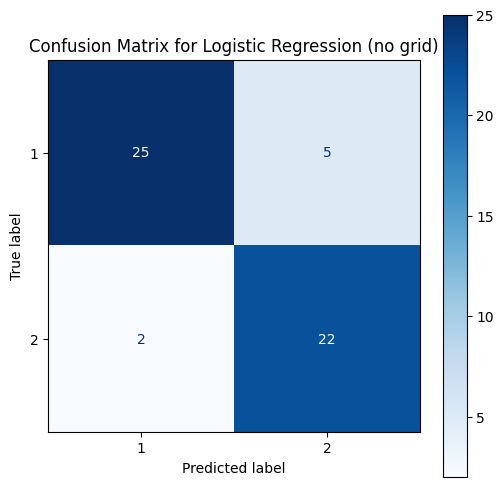

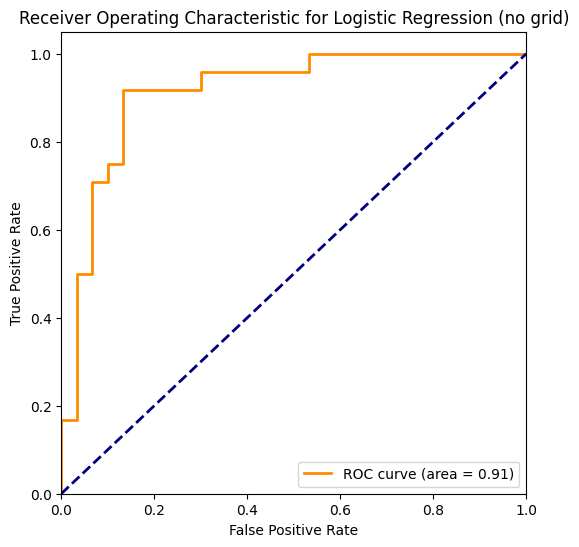

In [23]:
# TODO: create a Pipeline with your preprocessor and LogisticRegression
# Hint: solver 'liblinear' is fine, increase max_iter if needed
pipe_lr = Pipeline(steps=[
    ('preprocessor', pre),
    ('classifier', LogisticRegression(solver='liblinear', max_iter=1000, random_state=RANDOM_STATE))
])

# TODO: fit on training data
pipe_lr.fit(X_train, y_train)

# TODO: evaluate with eval_and_report
lr_no_gs_metrics = eval_and_report('Logistic Regression (no grid)', pipe_lr, X_test, y_test)


## Exercise 3 - Logistic Regression with Grid Search

Fitting 5 folds for each of 12 candidates, totalling 60 fits
Best params: {'lr__C': 0.1, 'lr__penalty': 'l2'}
LR grid Metrics: {'accuracy': 0.8703703703703703, 'precision': 0.8765432098765431, 'recall': 0.8703703703703703, 'f1': 0.8707717004930627}


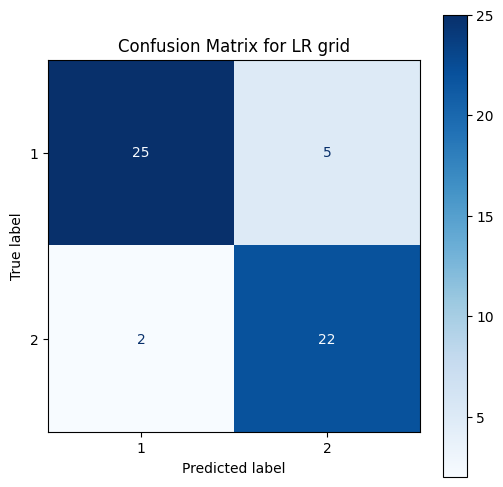

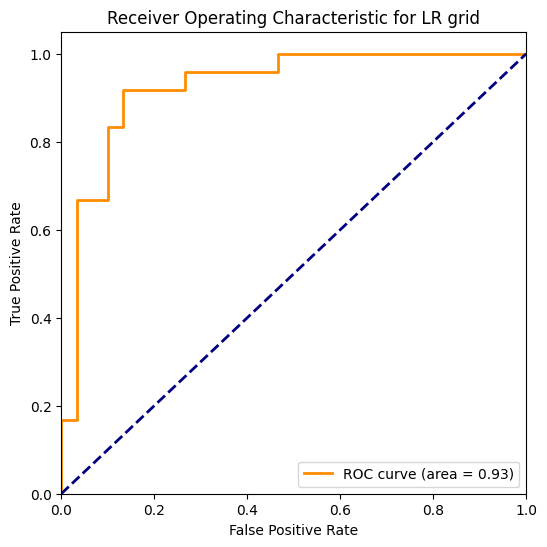

In [24]:
# TODO: build a Pipeline same as above
pipe_lr_cv = Pipeline(steps=[
    ('preprocessor', pre),
    ('lr', LogisticRegression(solver='liblinear', max_iter=1000, random_state=RANDOM_STATE))
])

# TODO: define param_grid for lr__C and lr__penalty
# Hint: use small to large C values. 'liblinear' supports 'l1' and 'l2'.
param_grid = {
    'lr__C': [0.001, 0.01, 0.1, 1, 10, 100],
    'lr__penalty': ['l1', 'l2'],
}

# TODO: GridSearchCV with cv=5 and scoring='f1'
grid_lr = GridSearchCV(pipe_lr_cv, param_grid, cv=5, scoring='f1_weighted', verbose=1, n_jobs=-1)
grid_lr.fit(X_train, y_train)
print('Best params:', grid_lr.best_params_)
best_lr = grid_lr.best_estimator_
lr_gs_metrics = eval_and_report('LR grid', best_lr, X_test, y_test)


## Exercise 4 - SVM without Grid Search

SVM no grid Metrics: {'accuracy': 0.8518518518518519, 'precision': 0.8620268620268621, 'recall': 0.8518518518518519, 'f1': 0.8522588522588521}


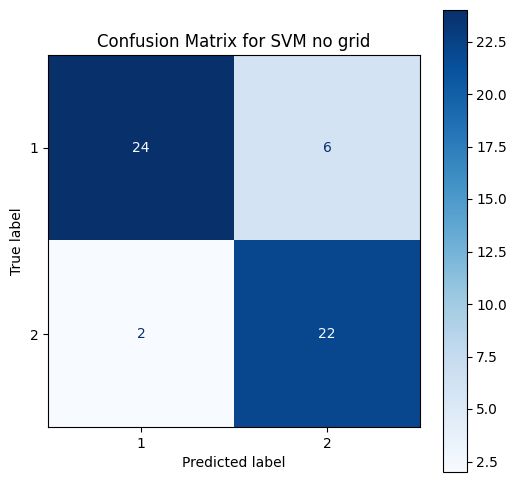

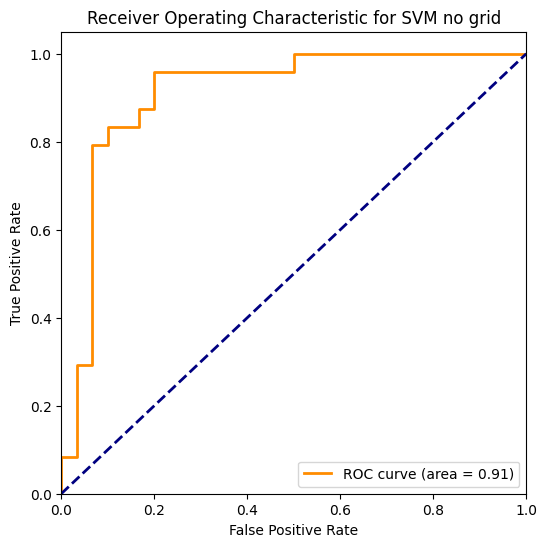

In [25]:
# TODO: choose kernel and hyperparameters for SVC
# Hint: try kernel='rbf' with C=1.0 and gamma='scale'
pipe_svm = Pipeline(steps=[
    ('preprocessor', pre),
    ('classifier', SVC(kernel='rbf', C=1.0, gamma='scale', random_state=RANDOM_STATE, probability=True))
])
pipe_svm.fit(X_train, y_train)
svm_no_metrics = eval_and_report('SVM no grid', pipe_svm, X_test, y_test)


## Exercise 5 - SVM with Grid Search

Fitting 5 folds for each of 32 candidates, totalling 160 fits
Best params: {'svm__C': 0.1, 'svm__gamma': 'scale', 'svm__kernel': 'linear'}
SVM grid Metrics: {'accuracy': 0.8518518518518519, 'precision': 0.8550061050061052, 'recall': 0.8518518518518519, 'f1': 0.8522605363984673}


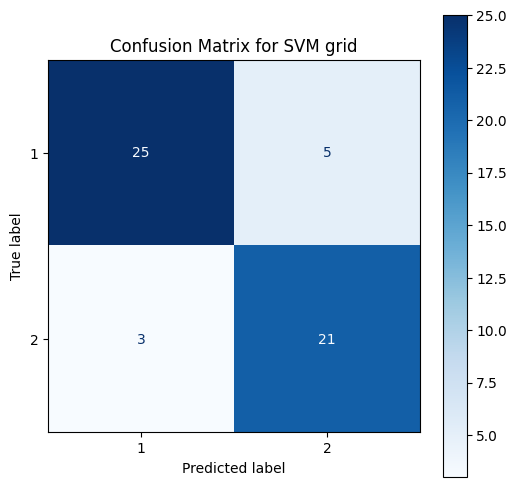

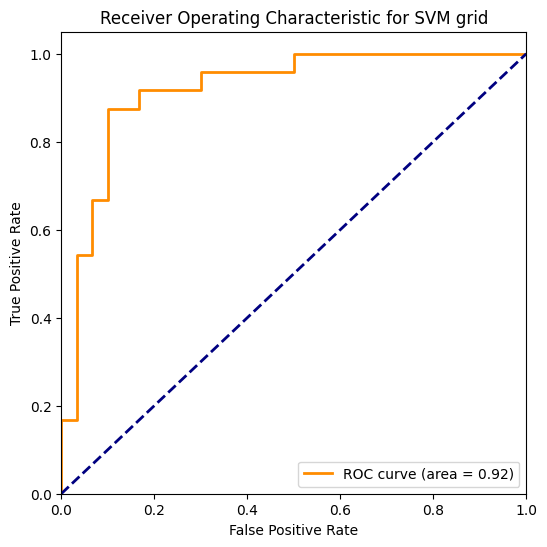

In [26]:
# TODO: Pipeline with SVC(probability=True) so you can plot ROC
pipe_svm_cv = Pipeline(steps=[
    ('preprocessor', pre),
    ('svm', SVC(random_state=RANDOM_STATE, probability=True))
])

# TODO: param_grid with svm__kernel, svm__C, svm__gamma
svm_param_grid = {
    'svm__kernel': ['rbf', 'linear'],
    'svm__C': [0.1, 1, 10, 100],
    'svm__gamma': ['scale', 'auto', 0.1, 1]
}

# TODO: GridSearchCV, fit, evaluate best estimator
grid_svm = GridSearchCV(pipe_svm_cv, svm_param_grid, cv=5, scoring='f1_weighted', verbose=1, n_jobs=-1)
grid_svm.fit(X_train, y_train)

print('Best params:', grid_svm.best_params_)
best_svm = grid_svm.best_estimator_
svm_gs_metrics = eval_and_report('SVM grid', best_svm, X_test, y_test)


## Exercise 6 - XGBoost without Grid Search

XGB no grid Metrics: {'accuracy': 0.8333333333333334, 'precision': 0.8344827586206897, 'recall': 0.8333333333333334, 'f1': 0.8336215842269111}


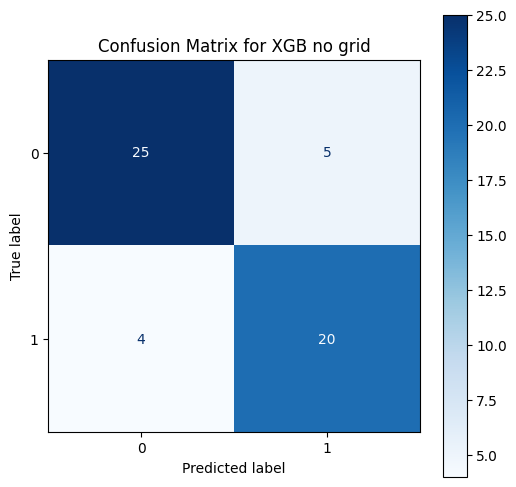

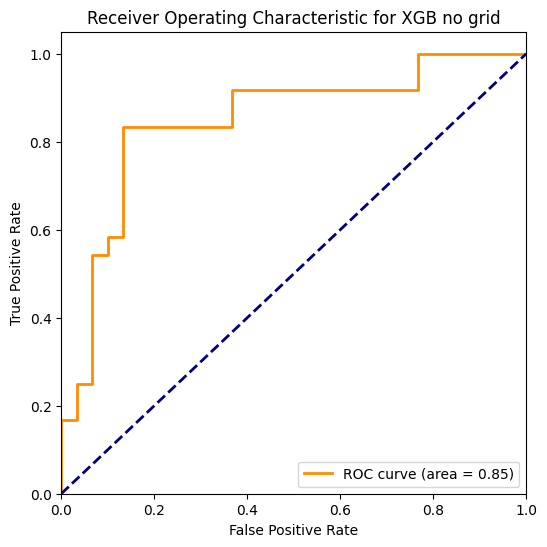

In [32]:
# TODO: build an XGBClassifier and wrap it in a Pipeline with pre
# Hint: start with n_estimators around 300, learning_rate 0.1, max_depth 3 to 5
pipe_xgb = Pipeline(steps=[
    ('preprocessor', pre),
    ('classifier', XGBClassifier(n_estimators=300, learning_rate=0.1, max_depth=3, random_state=RANDOM_STATE, eval_metric='logloss'))
])
pipe_xgb.fit(X_train, y_train)
xgb_no_metrics = eval_and_report('XGB no grid', pipe_xgb, X_test, y_test)


## Exercise 7 - XGBoost with Grid Search

Fitting 5 folds for each of 108 candidates, totalling 540 fits
Best params: {'xgb__colsample_bytree': 1.0, 'xgb__learning_rate': 0.2, 'xgb__max_depth': 7, 'xgb__n_estimators': 100, 'xgb__subsample': 1.0}
XGB grid Metrics: {'accuracy': 0.8148148148148148, 'precision': 0.818070818070818, 'recall': 0.8148148148148148, 'f1': 0.8153256704980844}


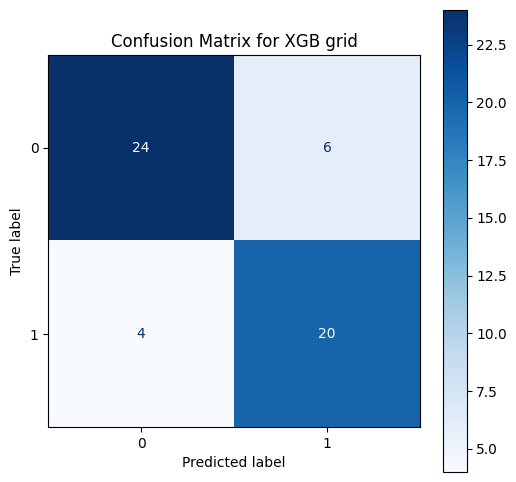

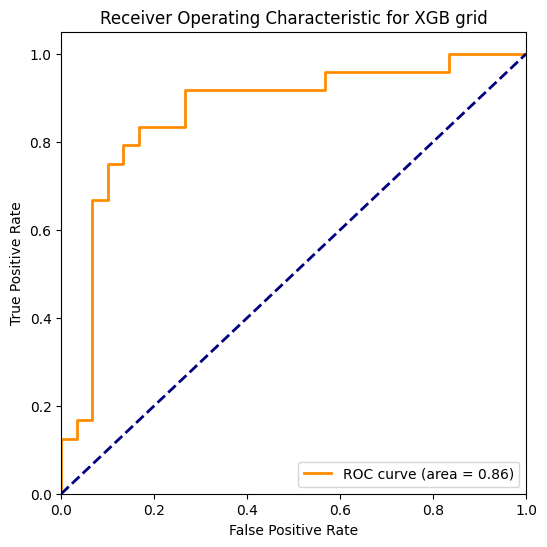

In [34]:
# TODO: Pipeline with XGBClassifier
pipe_xgb_cv = Pipeline(steps=[
    ('preprocessor', pre),
    ('xgb', XGBClassifier(random_state=RANDOM_STATE, eval_metric='logloss'))
])

# TODO: define a reasonable param_grid
xgb_param_grid = {
    'xgb__n_estimators': [100, 200, 300],
    'xgb__learning_rate': [0.01, 0.1, 0.2],
    'xgb__max_depth': [3, 5, 7],
    'xgb__subsample': [0.8, 1.0],
    'xgb__colsample_bytree': [0.8, 1.0],
}

# TODO: GridSearchCV, fit, evaluate best estimator
grid_xgb = GridSearchCV(pipe_xgb_cv, xgb_param_grid, cv=5, scoring='f1_weighted', verbose=1, n_jobs=-1)
grid_xgb.fit(X_train, y_train)

print('Best params:', grid_xgb.best_params_)
best_xgb = grid_xgb.best_estimator_
xgb_gs_metrics = eval_and_report('XGB grid', best_xgb, X_test, y_test)


## Compare models

In [35]:
# TODO: build a comparison DataFrame from your metrics dicts
# Hint: pd.DataFrame.from_dict(metrics, orient='index')
summary = {}
summary['LR no grid'] = lr_no_gs_metrics
summary['LR grid'] = lr_gs_metrics
summary['SVM no grid'] = svm_no_metrics
summary['SVM grid'] = svm_gs_metrics
summary['XGB no grid'] = xgb_no_metrics
summary['XGB grid'] = xgb_gs_metrics

summary_df = pd.DataFrame.from_dict(summary, orient='index')
display(summary_df)

,accuracy,precision,recall,f1
LR no grid,0.870370,0.876543,0.870370,0.870772
LR grid,0.870370,0.876543,0.870370,0.870772
SVM no grid,0.851852,0.862027,0.851852,0.852259
SVM grid,0.851852,0.855006,0.851852,0.852261
XGB no grid,0.833333,0.834483,0.833333,0.833622
XGB grid,0.814815,0.818071,0.814815,0.815326
